In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_glw = pd.read_csv("glw.csv")
df_glw["class"] = "GLWa"
df_rpa = pd.read_csv("rpa.csv")
df_rpa["class"] = "RPa"
df_wt = pd.read_csv("wt.csv")
df_wt["class"] = "Wild Type"
df = pd.concat([df_glw, df_rpa, df_wt])
df.head()

,id,mean_width_microns,mean_height_microns,avg_direction_radians,avg_speed_mps,total_distance_microns,distance_change_microns,min_width_microns,max_width_microns,min_height_microns,max_heigh_microns,class
0,0,265.433177,269.122358,2.846161,655.001901,39256.447245,186.550261,214.285714,364.285714,170.011806,340.023613,GLWa
1,1,217.978242,220.901944,2.001472,363.321426,21775.064151,441.387018,192.857143,300.000000,191.263282,297.520661,GLWa
2,2,271.234019,269.772069,2.775141,610.394335,36582.967119,408.963629,214.285714,342.857143,212.514758,340.023613,GLWa
3,3,234.737553,236.471397,2.788281,603.282548,36156.734015,100.001250,192.857143,321.428571,212.514758,297.520661,GLWa
4,4,253.188279,257.900066,2.745678,516.200410,30937.611222,52.690132,214.285714,342.857143,212.514758,361.275089,GLWa


<Axes: xlabel='total_distance_microns', ylabel='Density'>

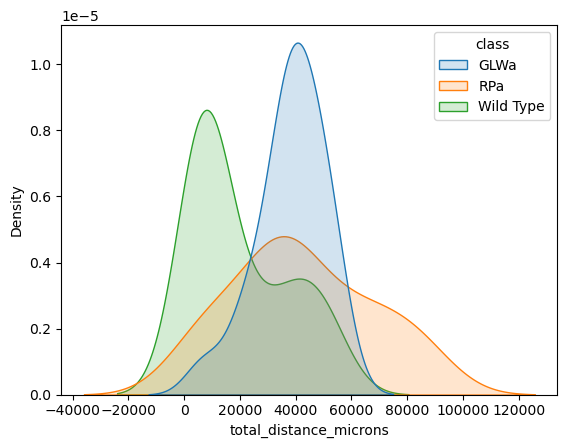

In [3]:
sns.kdeplot(data = df, x = "total_distance_microns", hue = "class", fill = True, alpha = 0.2)

<Axes: xlabel='mean_width_microns', ylabel='Density'>

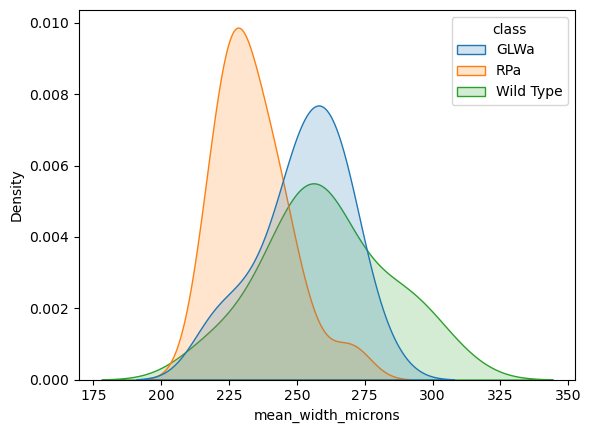

In [4]:
sns.kdeplot(data = df, x = "mean_width_microns", hue = "class", fill = True, alpha = 0.2)

<Axes: xlabel='mean_height_microns', ylabel='Density'>

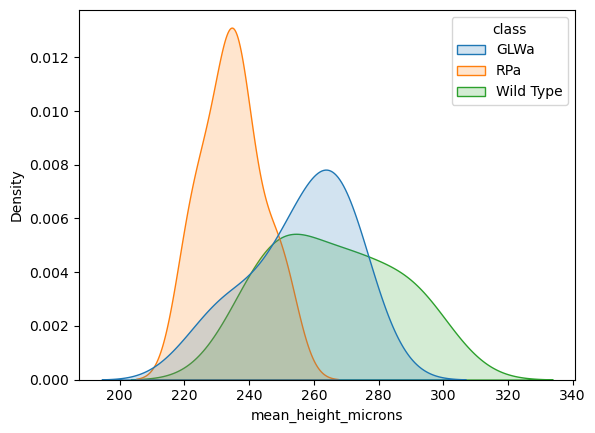

In [5]:
sns.kdeplot(data = df, x = "mean_height_microns", hue = "class", fill = True, alpha = 0.2)

In [6]:
import umap
reducer = umap.UMAP()

df_reduced = df.filter(items = ["mean_width_microns", "mean_height_microns", 
                                "avg_direction_radians", "avg_speed_mps", 
                                "total_distance_microns", "distance_change_microns",
                                "min_width_microns", "max_width_microns",
                                "min_height_microns", "max_heigh_microns"])
embedding = reducer.fit_transform(df_reduced)
embedding.shape

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


(60, 2)

In [7]:
embedding

array([[-0.02561125,  4.9551635 ],
       [-4.6810107 ,  4.5456643 ],
       [-1.4717469 ,  5.0019407 ],
       [-1.6912664 ,  4.883418  ],
       [-3.2482533 ,  4.2612424 ],
       [-1.5112271 ,  4.654946  ],
       [-3.6495678 ,  4.0734425 ],
       [ 1.3235782 ,  6.372217  ],
       [ 2.108788  ,  6.9100785 ],
       [ 0.4074265 ,  5.3484383 ],
       [ 1.7258334 ,  7.232094  ],
       [ 1.5600528 ,  6.7020125 ],
       [ 1.0250262 ,  5.5283313 ],
       [-5.0961633 ,  4.681924  ],
       [ 0.81545347,  5.148156  ],
       [ 2.1796896 ,  7.5501504 ],
       [-7.878393  ,  5.517383  ],
       [-2.4370425 ,  4.5978765 ],
       [ 0.58715904,  5.6382117 ],
       [ 1.9002075 ,  7.5008307 ],
       [-3.1978734 ,  4.3790374 ],
       [-7.2390375 ,  5.223579  ],
       [ 3.0957296 ,  7.5511913 ],
       [-7.1615553 ,  4.815558  ],
       [-1.3224056 ,  4.9234266 ],
       [-6.866045  ,  4.95106   ],
       [ 2.5940917 ,  7.87198   ],
       [ 2.8960142 ,  7.4832945 ],
       [-2.207724  ,

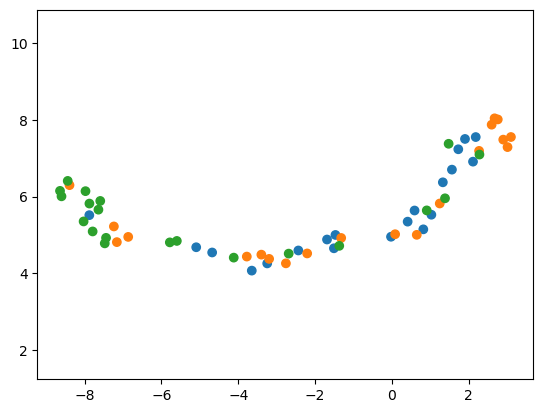

In [8]:
plt.scatter(embedding[:, 0], embedding[:, 1],
    c=[sns.color_palette()[x] for x in df["class"].map({"GLWa":0, "RPa":1, "Wild Type":2})])
plt.gca().set_aspect('equal', 'datalim')

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(df_reduced)

PCA(n_components=2)

In [10]:
print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[9.99915238e-01 7.48320798e-05]
[160873.8875387   1391.7071908]


In [11]:
df_pca = pca.transform(df_reduced)

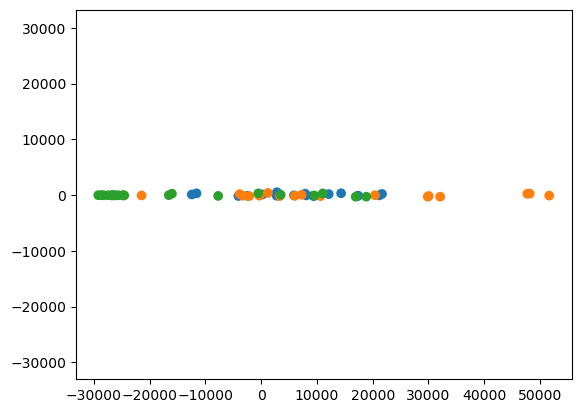

In [12]:
plt.scatter(df_pca[:, 0], df_pca[:, 1],
    c=[sns.color_palette()[x] for x in df["class"].map({"GLWa":0, "RPa":1, "Wild Type":2})])
plt.gca().set_aspect('equal', 'datalim')

## Travelers vs Spiralers vs Nonmovers

Here, I define a traveler as moving more than 200 microns (0.2mm, or around 10 pixels) from its starting point. If not a traveler, a spiraler travels more than 20000 total microns. If neither of those, it's a nonmover.

In [13]:
movement_types = []
for i in range(len(df)):
    current_travel = df.iloc[i]["total_distance_microns"]
    current_change = df.iloc[i]["distance_change_microns"]

    if current_change > 200:
        movement_types.append("Traveler")
        continue
    elif current_travel > 20000:
        movement_types.append("Spiraler")
        continue
    else:
        movement_types.append("Nonmover")

df["movement_type"] = movement_types

In [ ]:
g = sns.catplot(
    data=df, kind="bar",
    x="movement_type", y="body_mass_g", hue="sex",
    errorbar="sd", palette="dark", alpha=.6, height=6
)